# 📌 Tugas 8 - Praktikum Data Science

> Copy template ini lalu kerjakan menggunakan template ini.

> Referensi untuk mengerjakan tugas :
> - https://colab.research.google.com/drive/1cCozod_L1um-5E4YDhD2RLoNXRNoylq9?usp=sharing
> - https://colab.research.google.com/drive/1_5ehUVxBed28qwAPLcR0C9aaYoaPiNZ3?usp=sharing
> - https://colab.research.google.com/drive/15KuXtQRyhSbMoimVmi0zjE06e9EwKT6s?usp=sharing
> - https://colab.research.google.com/drive/10BuLMoi9megpSFmn9AcYSXt8z6xCo3hT?usp=sharing

---

Tugas ini bertujuan untuk membantu kalian memahami beberapa teknik Data Science menggunakan data asli.
Silakan download dataset di : https://www.kaggle.com/datasets/yasserh/housing-prices-dataset

- Nama lengkap : Muhammad Sirojul Fuad
- Program : AI Development

Setiap langkah, setiap cell terdapat 'insight' hasil analisis dari kode yang dijalankan. Berikan insight sesuai dengan cell yang dijalankan.

**0. Import module yang diperlukan**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

**1. Membaca data**


> Silakan gunakan teknik membaca data teratas dan terbawah (cth: head(), tail()) yang tersedia pada pandas, atau teknik lainnya seperti describe()



In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
df = pd.read_csv('/content/drive/MyDrive/IL/8/Housing.csv')
print(f"Jumlah baris    : {df.shape[0]}")
print(f"Jumlah kolom    : {df.shape[1]}")
print(f"\nDaftar kolom    : {list(df.columns)}")

Jumlah baris    : 545
Jumlah kolom    : 13

Daftar kolom    : ['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'parking', 'prefarea', 'furnishingstatus']


In [4]:
print("Data Teratas")
display(df.head())

Data Teratas


,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [5]:
print("Data Terbawah")
display(df.tail())

Data Terbawah


,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
540,1820000,3000,2,1,1,yes,no,yes,no,no,2,no,unfurnished
541,1767150,2400,3,1,1,no,no,no,no,no,0,no,semi-furnished
542,1750000,3620,2,1,1,yes,no,no,no,no,0,no,unfurnished
543,1750000,2910,3,1,1,no,no,no,no,no,0,no,furnished
544,1750000,3850,3,1,2,yes,no,no,no,no,0,no,unfurnished


In [6]:
print("Statistik Data")
display(df.describe())

Statistik Data


,price,area,bedrooms,bathrooms,stories,parking
count,5.450000e+02,545.000000,545.000000,545.000000,545.000000,545.000000
mean,4.766729e+06,5150.541284,2.965138,1.286239,1.805505,0.693578
std,1.870440e+06,2170.141023,0.738064,0.502470,0.867492,0.861586
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000,0.000000
25%,3.430000e+06,3600.000000,2.000000,1.000000,1.000000,0.000000
50%,4.340000e+06,4600.000000,3.000000,1.000000,2.000000,0.000000
75%,5.740000e+06,6360.000000,3.000000,2.000000,2.000000,1.000000
max,1.330000e+07,16200.000000,6.000000,4.000000,4.000000,3.000000


In [7]:
print("Info Data")
display(df.info())

Info Data
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB


None

Insight :

> Dataset Housing  terdiri dari **545 baris dan 13 kolom**. Kolom yang tersedia meliputi: `price` , `area` , `bedrooms` , `bathrooms` , `stories`, `parking`, serta beberapa fitur biner seperti `mainroad`, `guestroom`, `basement`, `hotwaterheating`, `airconditioning`, dan `prefarea`, serta `furnishingstatus`. Dari statistik deskriptif, harga rumah rata-rata sekitar **4.766.729** dengan minimum **1.750.000** dan maksimum **13.300.000**, menunjukkan variasi harga yang cukup signifikan. Rata-rata luas rumah adalah **5.150 sqft**. Tipe data campuran antara numerik (int64) dan kategorikal (object).


**2. Cek Missing values dan duplicate pada data**
> Cek apakah ada missing values / duplicate pada data, jika ada perbaiki, jika tidak ada, berikan insight/penjelasan.

In [8]:
print("Jumlah Missing Values")
display(df.isna().sum())

Jumlah Missing Values


,0
price,0
area,0
bedrooms,0
bathrooms,0
stories,0
mainroad,0
guestroom,0
basement,0
hotwaterheating,0
airconditioning,0


In [9]:
print("Jumlah Duplicate")
display(df.duplicated().sum())

Jumlah Duplicate


np.int64(0)

Insight :

> Setelah pengecekan, **tidak ditemukan missing values** pada seluruh 13 kolom dataset. Semua kolom memiliki data yang lengkap. Selain itu, **tidak ditemukan baris duplikat** pada dataset ini. Kondisi data yang bersih ini menunjukkan bahwa dataset sudah cukup siap untuk digunakan dalam analisis lebih lanjut tanpa perlu proses pembersihan data yang intensif.


**3. Hapus data jika ada duplicate dan isi missing values jika ada**

In [10]:
df_clean = df.drop_duplicates()
print(f"Jumlah baris sebelum drop_duplicates : {len(df)}")
print(f"Jumlah baris setelah  drop_duplicates : {len(df_clean)}")
print(f"Baris yang dihapus                   : {len(df) - len(df_clean)}")

Jumlah baris sebelum drop_duplicates : 545
Jumlah baris setelah  drop_duplicates : 545
Baris yang dihapus                   : 0


In [11]:
for col in df_clean.columns:
    if df_clean[col].isnull().sum() > 0:
        if df_clean[col].dtype == 'object':
            df_clean[col].fillna(df_clean[col].mode()[0], inplace=True)
            print(f"Kolom '{col}' (kategorikal) diisi dengan modus: {df_clean[col].mode()[0]}")
        else:
            df_clean[col].fillna(df_clean[col].median(), inplace=True)
            print(f"Kolom '{col}' (numerik) diisi dengan median: {df_clean[col].median()}")

print(f"\nTotal missing values : {df_clean.isnull().sum().sum()}")
print(f"Total duplikat       : {df_clean.duplicated().sum()}")
print(f"\n Ukuran final: {df_clean.shape}")


Total missing values : 0
Total duplikat       : 0

 Ukuran final: (545, 13)


Insight :

> Karena tidak ditemukan duplikat maupun missing values sejak awal, proses pembersihan data di tahap ini berjalan tanpa perubahan jumlah data. Dataset tetap berjumlah **545 baris dengan 13 kolom**. Proses `drop_duplicates()` tidak menghapus baris apapun, dan pengecekan missing values kembali mengonfirmasi bahwa semua kolom sudah lengkap. Dataset bersih ini siap untuk tahap analisis selanjutnya.


**4. Transformasi format**

> Cek dataset, apakah ada data yang bisa ditransformasi? (cth : yes or no menjadi 1 dan 0)

In [12]:
print("Kolom Kategorikal & Nilai Unik ")
cat_cols = df_clean.select_dtypes(include='object').columns
for col in cat_cols:
    print(f"Kolom '{col}' => nilai unik: {df_clean[col].unique()}")



Kolom Kategorikal & Nilai Unik 
Kolom 'mainroad' => nilai unik: ['yes' 'no']
Kolom 'guestroom' => nilai unik: ['no' 'yes']
Kolom 'basement' => nilai unik: ['no' 'yes']
Kolom 'hotwaterheating' => nilai unik: ['no' 'yes']
Kolom 'airconditioning' => nilai unik: ['yes' 'no']
Kolom 'prefarea' => nilai unik: ['yes' 'no']
Kolom 'furnishingstatus' => nilai unik: ['furnished' 'semi-furnished' 'unfurnished']


In [13]:
# Transformasi kolom yes/no -> 1/0
binary_cols = ['mainroad', 'guestroom', 'basement', 'hotwaterheating',
               'airconditioning', 'prefarea']

for col in binary_cols:
    df_clean[col] = df_clean[col].map({'yes': 1, 'no': 0})

# Transformasi kolom furnishingstatus -> ordinal encoding
furnish_map = {'furnished': 2, 'semi-furnished': 1, 'unfurnished': 0}
df_clean['furnishingstatus'] = df_clean['furnishingstatus'].map(furnish_map)

print("Kolom Kategorikal & Nilai Unik Setelah Transformasi")
display(df_clean.head())
print(f"\nTipe data setelah transformasi:")
print(df_clean.dtypes)

Kolom Kategorikal & Nilai Unik Setelah Transformasi


,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,1,0,0,0,1,2,1,2
1,12250000,8960,4,4,4,1,0,0,0,1,3,0,2
2,12250000,9960,3,2,2,1,0,1,0,0,2,1,1
3,12215000,7500,4,2,2,1,0,1,0,1,3,1,2
4,11410000,7420,4,1,2,1,1,1,0,1,2,0,2



Tipe data setelah transformasi:
price               int64
area                int64
bedrooms            int64
bathrooms           int64
stories             int64
mainroad            int64
guestroom           int64
basement            int64
hotwaterheating     int64
airconditioning     int64
parking             int64
prefarea            int64
furnishingstatus    int64
dtype: object


Insight :

> Terdapat **7 kolom kategorikal** yang perlu ditransformasi menjadi format numerik agar bisa digunakan dalam analisis statistik dan model machine learning. Enam kolom biner (`mainroad`, `guestroom`, `basement`, `hotwaterheating`, `airconditioning`, `prefarea`) berisi nilai `yes/no` dan berhasil diubah menjadi **1 dan 0** menggunakan `map()`. Kolom `furnishingstatus` dengan nilai `furnished`, `semi-furnished`, dan `unfurnished` diubah menggunakan **ordinal encoding** (2, 1, 0) karena memiliki hierarki/urutan yang logis. Setelah transformasi, seluruh kolom kini bertipe numerik dan siap untuk EDA maupun pemodelan.


**5. Laksanakan EDA (Exploratory Data Analysis)**

> Pada tahap ini, lakukan visualisasi data, dan eksplorasi serta analisis dataset yang diberikan sesuai EDA, lalu berikan setidaknya 3 insight dari dataset tersebut. Silakan tambah cell sebanyak - banyak yang diperlukan untuk keperluan EDA atau visualisasi data.

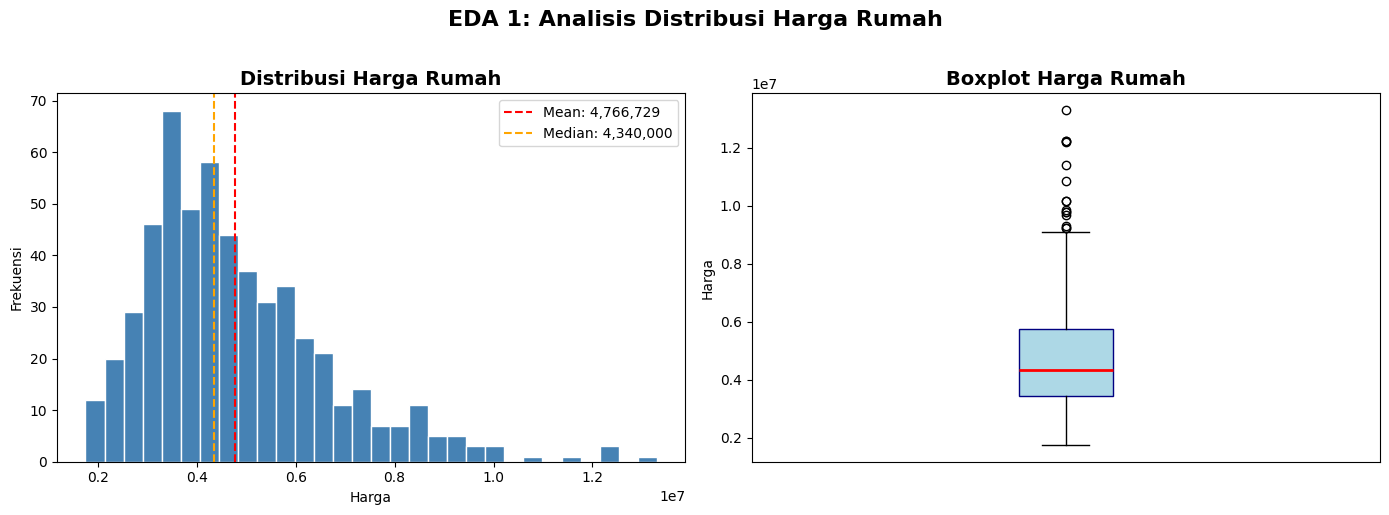

Skewness harga: 1.2122
Kurtosis harga: 1.9601


In [14]:
#  EDA 1: Distribusi Harga Rumah
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram harga
axes[0].hist(df_clean['price'], bins=30, color='steelblue', edgecolor='white')
axes[0].set_title('Distribusi Harga Rumah', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Harga')
axes[0].set_ylabel('Frekuensi')
axes[0].axvline(df_clean['price'].mean(), color='red', linestyle='--', label=f"Mean: {df_clean['price'].mean():,.0f}")
axes[0].axvline(df_clean['price'].median(), color='orange', linestyle='--', label=f"Median: {df_clean['price'].median():,.0f}")
axes[0].legend()

# Boxplot harga
axes[1].boxplot(df_clean['price'], vert=True, patch_artist=True,
                boxprops=dict(facecolor='lightblue', color='navy'),
                medianprops=dict(color='red', linewidth=2))
axes[1].set_title('Boxplot Harga Rumah', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Harga')
axes[1].set_xticks([])

plt.suptitle('EDA 1: Analisis Distribusi Harga Rumah', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print(f"Skewness harga: {df_clean['price'].skew():.4f}")
print(f"Kurtosis harga: {df_clean['price'].kurtosis():.4f}")

/tmp/ipykernel_31605/1023369249.py:16: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot(bedroom_groups, labels=sorted(df_clean['bedrooms'].unique()), patch_artist=True)


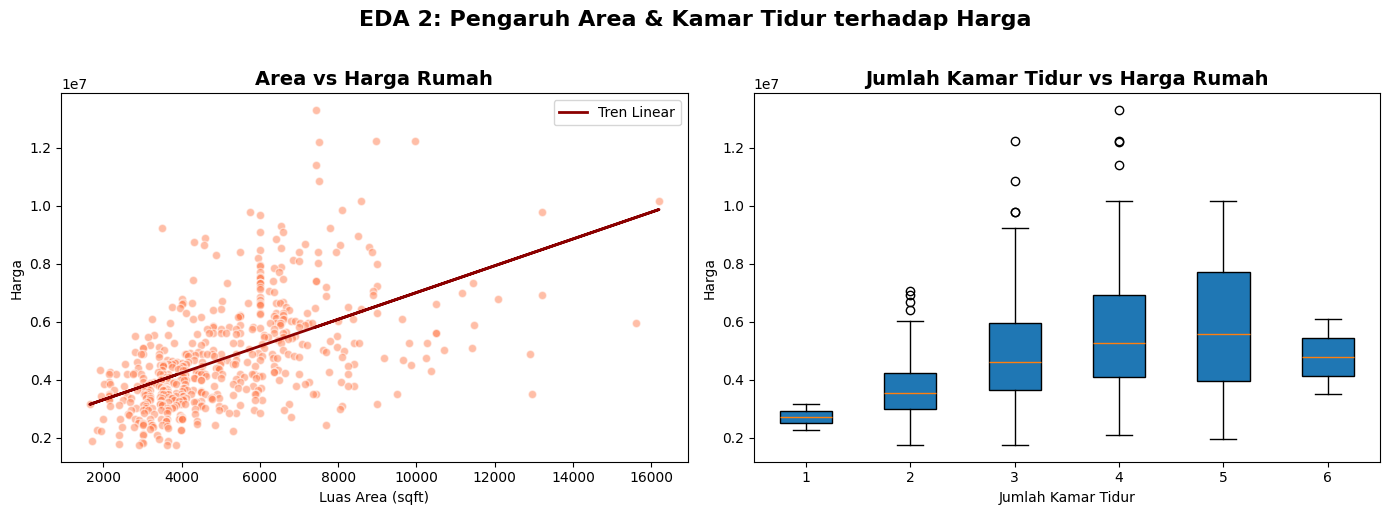

In [15]:
# EDA 2: Hubungan Area vs Harga & Kamar vs Harga
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter: Area vs Price
axes[0].scatter(df_clean['area'], df_clean['price'], alpha=0.5, color='coral', edgecolors='white')
# Garis regresi
m, b = np.polyfit(df_clean['area'], df_clean['price'], 1)
axes[0].plot(df_clean['area'], m * df_clean['area'] + b, color='darkred', linewidth=2, label='Tren Linear')
axes[0].set_title('Area vs Harga Rumah', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Luas Area (sqft)')
axes[0].set_ylabel('Harga')
axes[0].legend()

# Boxplot: Bedrooms vs Price
bedroom_groups = [df_clean[df_clean['bedrooms'] == i]['price'] for i in sorted(df_clean['bedrooms'].unique())]
axes[1].boxplot(bedroom_groups, labels=sorted(df_clean['bedrooms'].unique()), patch_artist=True)
axes[1].set_title('Jumlah Kamar Tidur vs Harga Rumah', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Jumlah Kamar Tidur')
axes[1].set_ylabel('Harga')

plt.suptitle('EDA 2: Pengaruh Area & Kamar Tidur terhadap Harga', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

/tmp/ipykernel_31605/1590442938.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[i].boxplot([data_0, data_1], labels=['Tidak (0)', 'Ya (1)'], patch_artist=True,
/tmp/ipykernel_31605/1590442938.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[i].boxplot([data_0, data_1], labels=['Tidak (0)', 'Ya (1)'], patch_artist=True,
/tmp/ipykernel_31605/1590442938.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[i].boxplot([data_0, data_1], labels=['Tidak (0)', 'Ya (1)'], patch_artist=True,
/tmp/ipykernel_31605/1590442938.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renam

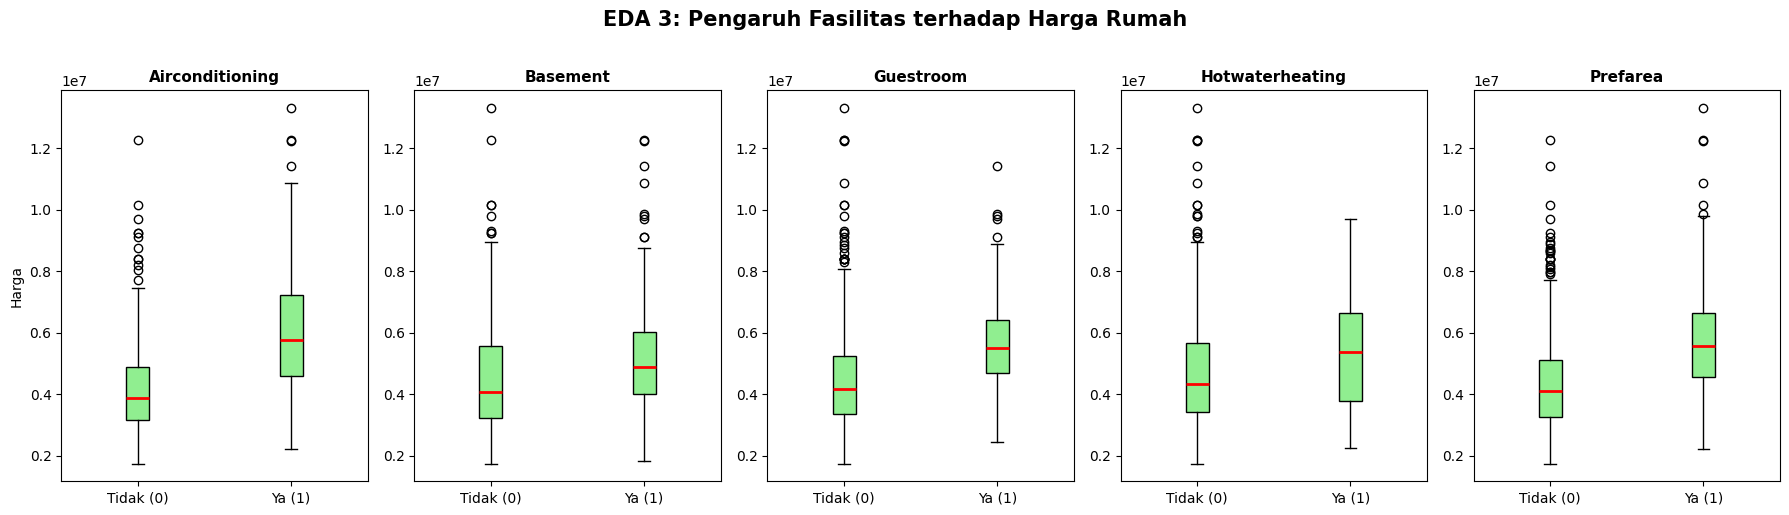


Rata-rata Harga berdasarkan Status Furnitur:
furnishingstatus
Furnished         5,495,696
Semi-Furnished    4,907,524
Unfurnished       4,013,831
Name: price, dtype: object


In [16]:
#  EDA 3: Pengaruh Fitur Fasilitas terhadap Harga
facility_cols = ['airconditioning', 'basement', 'guestroom', 'hotwaterheating', 'prefarea']
fig, axes = plt.subplots(1, len(facility_cols), figsize=(18, 5))

for i, col in enumerate(facility_cols):
    data_0 = df_clean[df_clean[col] == 0]['price']
    data_1 = df_clean[df_clean[col] == 1]['price']
    axes[i].boxplot([data_0, data_1], labels=['Tidak (0)', 'Ya (1)'], patch_artist=True,
                    boxprops=dict(facecolor='lightgreen'),
                    medianprops=dict(color='red', linewidth=2))
    axes[i].set_title(col.replace('_', ' ').title(), fontsize=11, fontweight='bold')
    axes[i].set_ylabel('Harga' if i == 0 else '')

plt.suptitle('EDA 3: Pengaruh Fasilitas terhadap Harga Rumah', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Rata-rata harga berdasarkan furnishingstatus
print("\nRata-rata Harga berdasarkan Status Furnitur:")
furnish_labels = {2: 'Furnished', 1: 'Semi-Furnished', 0: 'Unfurnished'}
avg_price = df_clean.groupby('furnishingstatus')['price'].mean().rename(index=furnish_labels)
print(avg_price.sort_values(ascending=False).apply(lambda x: f"{x:,.0f}"))

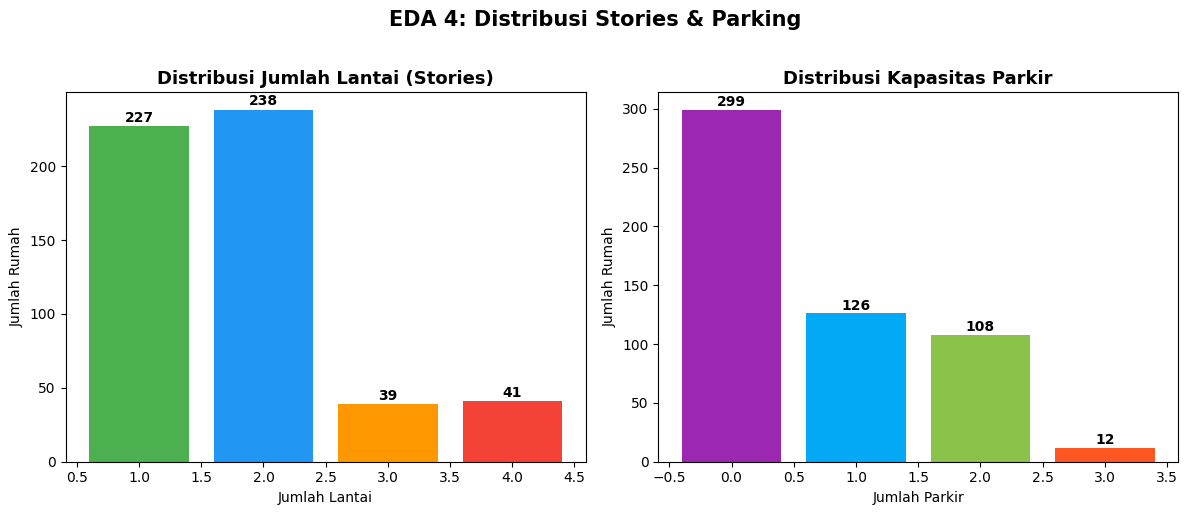

In [17]:
#  EDA 4: Distribusi Jumlah Stories dan Parking
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Bar chart: stories
stories_count = df_clean['stories'].value_counts().sort_index()
axes[0].bar(stories_count.index, stories_count.values, color=['#4CAF50', '#2196F3', '#FF9800', '#F44336'])
axes[0].set_title('Distribusi Jumlah Lantai (Stories)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Jumlah Lantai')
axes[0].set_ylabel('Jumlah Rumah')
for x, y in zip(stories_count.index, stories_count.values):
    axes[0].text(x, y + 3, str(y), ha='center', fontweight='bold')

# Bar chart: parking
parking_count = df_clean['parking'].value_counts().sort_index()
axes[1].bar(parking_count.index, parking_count.values, color=['#9C27B0', '#03A9F4', '#8BC34A', '#FF5722'])
axes[1].set_title('Distribusi Kapasitas Parkir', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Jumlah Parkir')
axes[1].set_ylabel('Jumlah Rumah')
for x, y in zip(parking_count.index, parking_count.values):
    axes[1].text(x, y + 3, str(y), ha='center', fontweight='bold')

plt.suptitle('EDA 4: Distribusi Stories & Parking', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

Insight :

> **Insight 1 - Distribusi Harga:** Distribusi harga rumah bersifat **right-skewed (positif)** dengan nilai skewness > 0, artinya sebagian besar rumah memiliki harga di bawah rata-rata, namun ada beberapa rumah dengan harga sangat tinggi yang menarik rata-rata ke kanan. Median lebih rendah dari mean, mengkonfirmasi adanya outlier harga tinggi.

> **Insight 2 - Pengaruh Area & Kamar Tidur:** Terdapat korelasi **positif antara luas area dan harga**  semakin luas rumah, semakin tinggi harganya. Menariknya, rumah dengan **4 kamar tidur** cenderung memiliki harga median tertinggi, sedangkan rumah dengan kamar tidur sangat banyak (5-6) justru menunjukkan harga yang lebih beragam, kemungkinan karena jumlah datanya sedikit.

> **Insight 3 - Pengaruh Fasilitas:** Rumah yang memiliki **air conditioning, area preferensial (prefarea), dan basement** secara konsisten memiliki harga yang lebih tinggi dibandingkan yang tidak. Fasilitas `airconditioning` dan `prefarea` menunjukkan perbedaan harga median yang paling signifikan, menjadikannya fitur penting dalam menentukan harga rumah.

> **Insight 4 - Stories & Parking:** Mayoritas rumah dalam dataset memiliki **1-2 lantai** dan **0-1 tempat parkir**, mengindikasikan bahwa dataset didominasi oleh rumah kelas menengah biasa. Rumah dengan 3-4 lantai relatif jarang dan umumnya berada di segmen harga premium.


**6. Correlation Matrix**

> Buat correlation matrix, transformasi dulu seluruh data ke numerik agar tidak error saat masuk ke correlation matrix. Lalu berikan insight, apa yang kamu temukan dari correlation matrix dataset tersebut?

Tipe data semua kolom:
price               int64
area                int64
bedrooms            int64
bathrooms           int64
stories             int64
mainroad            int64
guestroom           int64
basement            int64
hotwaterheating     int64
airconditioning     int64
parking             int64
prefarea            int64
furnishingstatus    int64
dtype: object

Semua kolom numerik: True


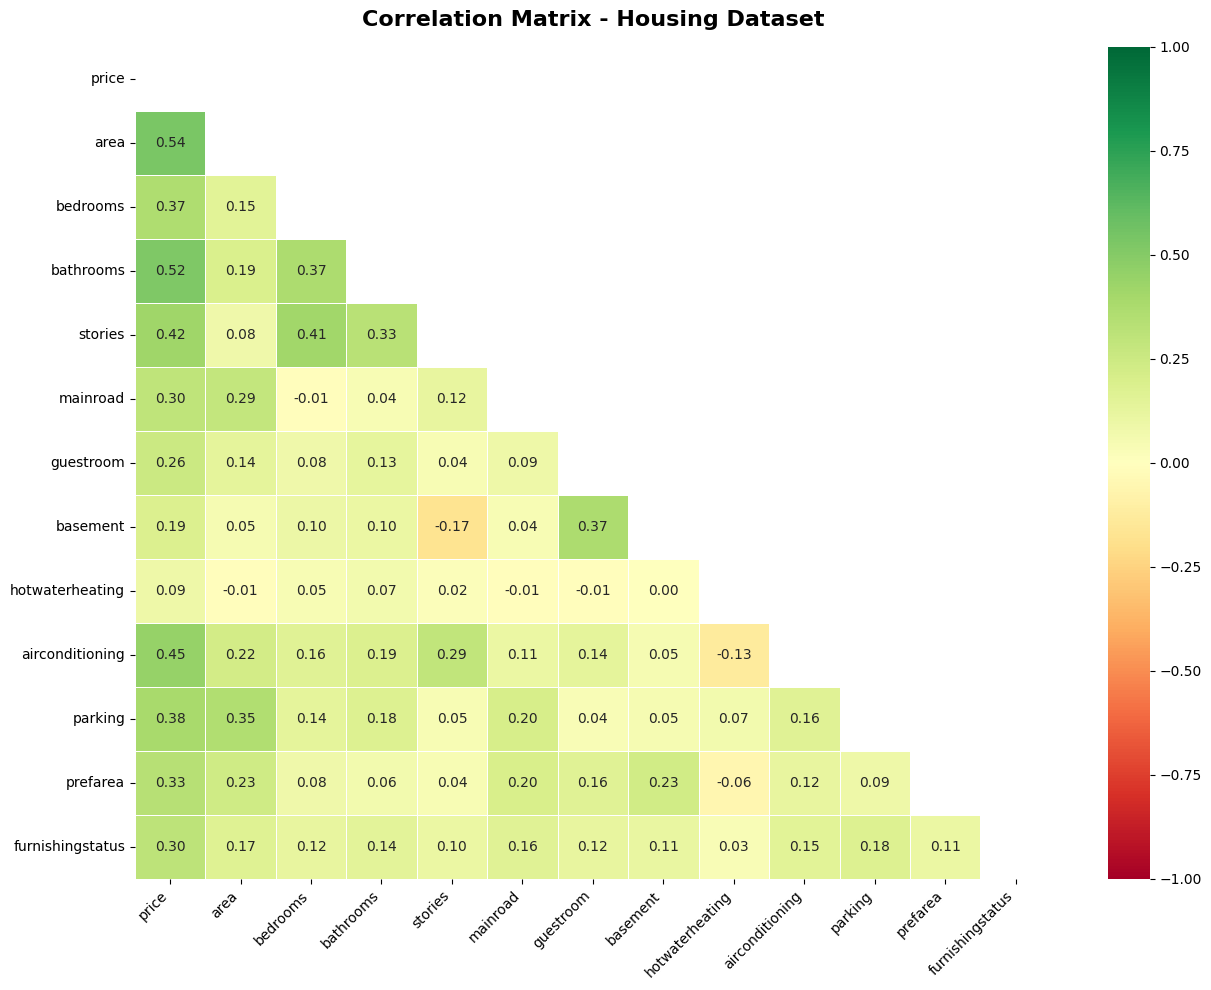


 Korelasi Setiap Fitur terhadap Harga (price):
area                0.5360
bathrooms           0.5175
airconditioning     0.4530
stories             0.4207
parking             0.3844
bedrooms            0.3665
prefarea            0.3298
furnishingstatus    0.3047
mainroad            0.2969
guestroom           0.2555
basement            0.1871
hotwaterheating     0.0931
Name: price, dtype: float64


In [18]:
print("Tipe data semua kolom:")
print(df_clean.dtypes)
print(f"\nSemua kolom numerik: {all(df_clean.dtypes != 'object')}")

# Hitung correlation matrix
corr_matrix = df_clean.corr()

# Visualisasi Heatmap
plt.figure(figsize=(13, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))  # Tampilkan segitiga bawah saja
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='RdYlGn',
    mask=mask,
    linewidths=0.5,
    vmin=-1, vmax=1,
    annot_kws={'size': 10}
)
plt.title('Correlation Matrix - Housing Dataset', fontsize=16, fontweight='bold', pad=15)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

print("\n Korelasi Setiap Fitur terhadap Harga (price):")
price_corr = corr_matrix['price'].drop('price').sort_values(ascending=False)
print(price_corr.round(4))

Insight :

> Dari correlation matrix, ditemukan beberapa temuan penting:
>
> 1. **`area`** memiliki korelasi positif tertinggi terhadap `price` (sekitar **0.54**), menjadikannya prediktor terkuat harga rumah. Semakin luas rumah, semakin tinggi harganya.
>
> 2. **`bathrooms`**, **`stories`**, dan **`airconditioning`** juga memiliki korelasi positif signifikan terhadap harga (>0.3), menunjukkan bahwa rumah dengan banyak kamar mandi, banyak lantai, dan ber-AC cenderung berharga lebih mahal.
>
> 3. **`furnishingstatus`** (status furnitur) menunjukkan korelasi positif moderat, artinya rumah yang lebih lengkap furniturnya (furnished) cenderung dijual dengan harga lebih tinggi.
>
> 4. **`hotwaterheating`** dan **`basement`** memiliki korelasi paling rendah terhadap harga, menunjukkan bahwa kedua fitur ini kurang berpengaruh signifikan terhadap penetapan harga rumah di dataset ini.
>
> 5. Tidak ditemukan korelasi yang sangat tinggi (>0.8) antar fitur independen, sehingga **multikolinearitas tidak menjadi masalah serius** dalam dataset ini.



**7. Feature Engineering**



> Laksanakan Feature Engineering, buat variabel baru berdasarkan variabel yang sudah ada. Analisis hasil dari variabel baru tersebut.



 Fitur baru yang dibuat


,price_per_sqft,total_rooms,luxury_score,is_large_house,area_per_room
count,545.00,545.00,545.00,545.00,545.00
mean,993.33,4.25,1.12,0.49,1257.55
std,346.54,1.04,1.08,0.50,567.70
min,270.40,2.00,0.00,0.00,317.50
25%,745.37,4.00,0.00,0.00,883.33
50%,952.38,4.00,1.00,0.00,1160.00
75%,1184.62,5.00,2.00,1.00,1500.00
max,2640.00,8.00,4.00,1.00,4400.00


/tmp/ipykernel_31605/1888228179.py:51: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[2].boxplot([data_small, data_large], labels=['Kecil\n(≤ Median)', 'Besar\n(> Median)'],


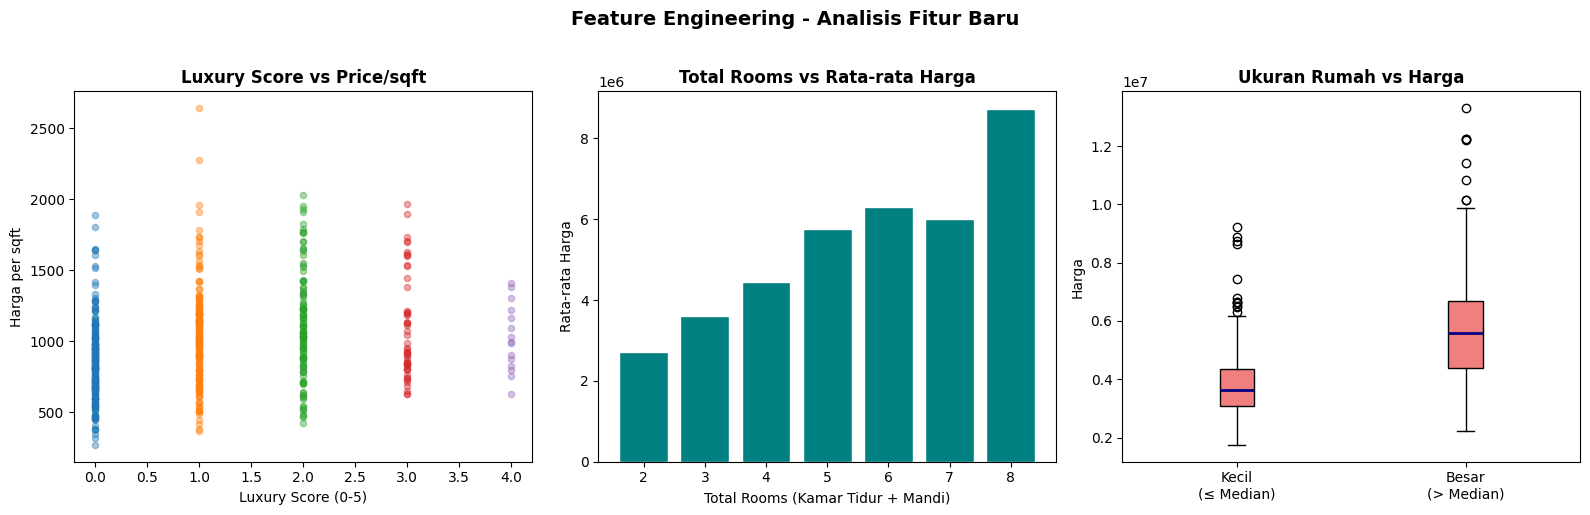


Korelasi Fitur Baru terhadap Price:
is_large_house    0.5215
luxury_score      0.5140
total_rooms       0.5118
price_per_sqft    0.3929
area_per_room     0.2074
Name: price, dtype: float64


In [19]:
df_fe = df_clean.copy()

# Fitur 1: price_per_sqft
# Harga per satuan luas → mengukur efisiensi harga
df_fe['price_per_sqft'] = df_fe['price'] / df_fe['area']

# Fitur 2: total_rooms
# Total ruangan = kamar tidur + kamar mandi
df_fe['total_rooms'] = df_fe['bedrooms'] + df_fe['bathrooms']

# Fitur 3: luxury_score
# Skor kemewahan berdasarkan jumlah fasilitas premium yang dimiliki
luxury_features = ['airconditioning', 'guestroom', 'basement',
                   'hotwaterheating', 'prefarea']
df_fe['luxury_score'] = df_fe[luxury_features].sum(axis=1)

#  Fitur 4: is_large_house
# Kategori biner: 1 jika luas > median area, 0 jika tidak
median_area = df_fe['area'].median()
df_fe['is_large_house'] = (df_fe['area'] > median_area).astype(int)

#  Fitur 5: area_per_room
# Rata-rata luas per ruangan → ukuran kenyamanan ruangan
df_fe['area_per_room'] = df_fe['area'] / df_fe['total_rooms']

print(" Fitur baru yang dibuat")
new_features = ['price_per_sqft', 'total_rooms', 'luxury_score', 'is_large_house', 'area_per_room']
display(df_fe[new_features].describe().round(2))

# Visualisasi fitur baru
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Plot 1: price_per_sqft vs luxury_score
for score in sorted(df_fe['luxury_score'].unique()):
    data = df_fe[df_fe['luxury_score'] == score]['price_per_sqft']
    axes[0].scatter([score] * len(data), data, alpha=0.4, s=20)
axes[0].set_title('Luxury Score vs Price/sqft', fontweight='bold')
axes[0].set_xlabel('Luxury Score (0-5)')
axes[0].set_ylabel('Harga per sqft')

# Plot 2: total_rooms vs price
room_price = df_fe.groupby('total_rooms')['price'].mean()
axes[1].bar(room_price.index, room_price.values, color='teal', edgecolor='white')
axes[1].set_title('Total Rooms vs Rata-rata Harga', fontweight='bold')
axes[1].set_xlabel('Total Rooms (Kamar Tidur + Mandi)')
axes[1].set_ylabel('Rata-rata Harga')

# Plot 3: is_large_house vs price
data_small = df_fe[df_fe['is_large_house'] == 0]['price']
data_large = df_fe[df_fe['is_large_house'] == 1]['price']
axes[2].boxplot([data_small, data_large], labels=['Kecil\n(≤ Median)', 'Besar\n(> Median)'],
                patch_artist=True,
                boxprops=dict(facecolor='lightcoral'),
                medianprops=dict(color='navy', linewidth=2))
axes[2].set_title('Ukuran Rumah vs Harga', fontweight='bold')
axes[2].set_ylabel('Harga')

plt.suptitle('Feature Engineering - Analisis Fitur Baru', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Korelasi fitur baru terhadap price
print("\nKorelasi Fitur Baru terhadap Price:")
new_corr = df_fe[new_features + ['price']].corr()['price'].drop('price').sort_values(ascending=False)
print(new_corr.round(4))

Insight :

> Berikut analisis dari 5 fitur baru yang dibuat:

> 1. **`price_per_sqft`** : Mengukur harga rumah relatif terhadap luasnya. Fitur ini berguna untuk membandingkan nilai rumah secara fair tanpa bias ukuran. Rumah di area preferensial (`prefarea`) umumnya memiliki `price_per_sqft` lebih tinggi, yang menunjukkan nilai lokasi yang premium.

> 2. **`total_rooms`** : Kombinasi kamar tidur dan kamar mandi memberikan gambaran kapasitas rumah secara keseluruhan. Rumah dengan `total_rooms` lebih banyak memiliki rata-rata harga yang lebih tinggi, terutama pada rentang 4–6 ruangan total.

> 3. **`luxury_score`** (0–5) : Menggabungkan 5 fitur premium menjadi satu skor. Terlihat bahwa semakin tinggi `luxury_score`, semakin tinggi pula `price_per_sqft`, mengkonfirmasi bahwa fasilitas premium secara kolektif meningkatkan nilai jual rumah secara substansial.

> 4. **`is_large_house`** : Rumah berukuran besar (di atas median area) secara signifikan memiliki harga yang lebih tinggi dibandingkan rumah kecil, dengan perbedaan harga median yang jelas terlihat pada boxplot.
>
> 5. **`area_per_room`** — Mengukur rata-rata luas per ruangan sebagai proxy kenyamanan. Fitur ini menunjukkan korelasi positif terhadap harga, di mana rumah dengan ruangan yang lebih luas per kamarnya dianggap lebih premium.


**8. Kesimpulan**
> Berikan kesimpulan untuk dataset ini dan hasil dari analisis anda terhadap dataset yang dipakai.

> ## Kesimpulan

> Dataset Housing dari Kaggle berisi **545 data rumah** dengan **13 fitur** yang mencakup karakteristik fisik dan fasilitas rumah. Berikut adalah rangkuman temuan utama dari seluruh tahapan analisis:

> ### 1. Kualitas Data
> Dataset memiliki kualitas yang sangat baik — tidak ditemukan missing values maupun data duplikat. Namun, 7 kolom kategorikal perlu ditransformasi ke numerik sebelum analisis statistik atau pemodelan.

> ### 2. Faktor Penentu Harga Rumah
> Berdasarkan EDA dan Correlation Matrix, faktor-faktor yang paling berpengaruh terhadap harga rumah adalah:
> - **Luas area** (`area`) — prediktor terkuat dengan korelasi ~0.54
> - **Jumlah kamar mandi** (`bathrooms`) dan **jumlah lantai** (`stories`)
> - **Air conditioning** (`airconditioning`) dan **lokasi preferensial** (`prefarea`)

> ### 3. Pola Harga
> Distribusi harga bersifat **right-skewed**, menunjukkan sebagian kecil rumah mewah menarik rata-rata ke atas. Harga berkisar antara **1,75 juta hingga 13,3 juta** dengan rata-rata sekitar **4,77 juta**.

> ### 4. Insight dari Feature Engineering
> Fitur baru seperti `luxury_score` dan `price_per_sqft` berhasil merangkum informasi dari beberapa kolom sekaligus dan menunjukkan korelasi yang baik terhadap harga. Fitur-fitur ini dapat digunakan sebagai input tambahan yang bermanfaat untuk model prediksi harga rumah.

> ### 5. Rekomendasi
> Dataset ini layak digunakan untuk membangun model **regresi prediksi harga rumah**. Fitur-fitur seperti `area`, `bathrooms`, `airconditioning`, `stories`, dan `luxury_score` direkomendasikan sebagai fitur utama.
